### Questions of Interest
* The bucket sizes Simmons uses were an arbitrary decision that was derived from the concept of reducing variation to reduce waste. How many buckets should Simmons be using and what sizes should the buckets be?
* Given Simmons target to eventually hit 75% upgrade, what "acceptable trim percentage" should be considered for determining bucket sizes?
* Simmons has expressed that they are hesitant to increase the probability of miscuts because they do not currently have the capacity to handle large amounts. Is there an acceptable tradeoff between trim and miscuts that will minimize yield? Is this path worth exploring?

# How do we account for the variation of weights in bucket size for calculating waste?

This dataset outlines three days worth of measurements from the x-ray machines on the processing line from Simmons poultry processing facility in Gentry, AR. The machines measure the weight (in pounds) of individual chicken breasts before they are sent to portioning facilities. The dataset contains three distributions: trim (small offcuts that mistakenly end up on the breast conveyors), single breasts, and butterflies (both breasts removed from the bird in one piece).

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from scipy.stats import norm
from scipy.signal import argrelextrema
from scipy.stats import skewnorm
from scipy.stats import chi2

In [5]:
# ingest data
df = pd.DataFrame(pd.read_csv('data/piecewise_data1.csv'))
df[['Weight (g)']] = df[['Weight (lb)']] * 453.592 # convert lbs to grams
x = df[['Weight (g)']].values
df.head()

,Material,Weight (lb),Piece type,PO,Shift,Batch,Grader,Gate number,Log time,Record type,Weight (g)
0,Wendy's,1.009724,NaN,NaN,Shift 3,NaN,SmartSort L 13-14,1,1/28/2026 12:01:00 AM,1,458.002729
1,Large,1.226967,NaN,NaN,Shift 3,NaN,SmartSort L 9-10,2,1/28/2026 12:01:00 AM,1,556.542415
2,Large,1.064304,NaN,NaN,Shift 3,NaN,SmartSort L 13-14,2,1/28/2026 12:01:00 AM,1,482.759780
3,Medium,0.656695,NaN,NaN,Shift 3,NaN,SmartSort L 11-12,3,1/28/2026 12:01:00 AM,1,297.871825
4,Large,1.157233,NaN,NaN,Shift 3,NaN,SmartSort L 3-4,2,1/28/2026 12:01:00 AM,1,524.911631


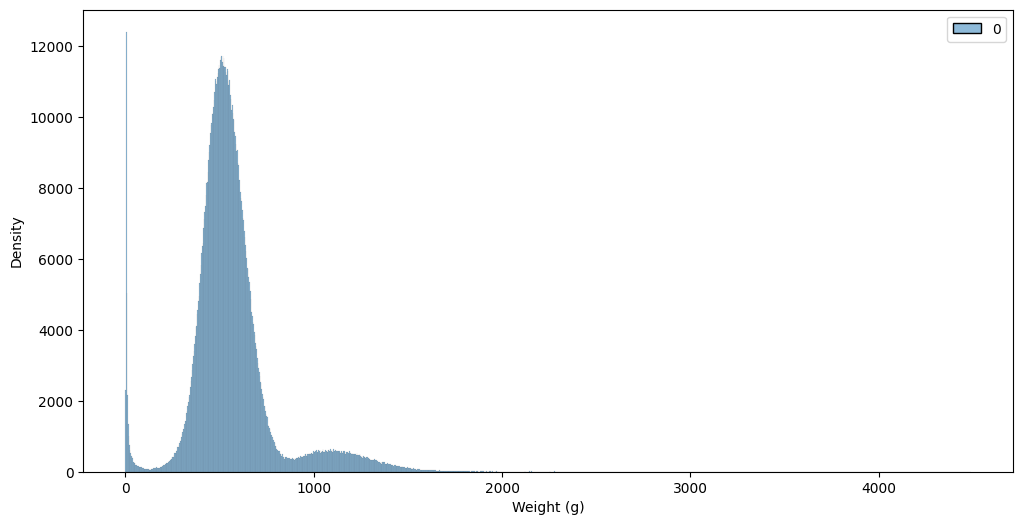

In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(x, color='blue')

plt.xlabel("Weight (g)")
plt.ylabel("Density")
plt.show()

## Identify Minima of Intrest
We are interested in the weights of single chicken breasts. The first step in preprocessing this dataset is to identify the bounds of my distribution of interest. To do that I need to find the minima surrounding this distribution.

<Figure size 1200x600 with 0 Axes>

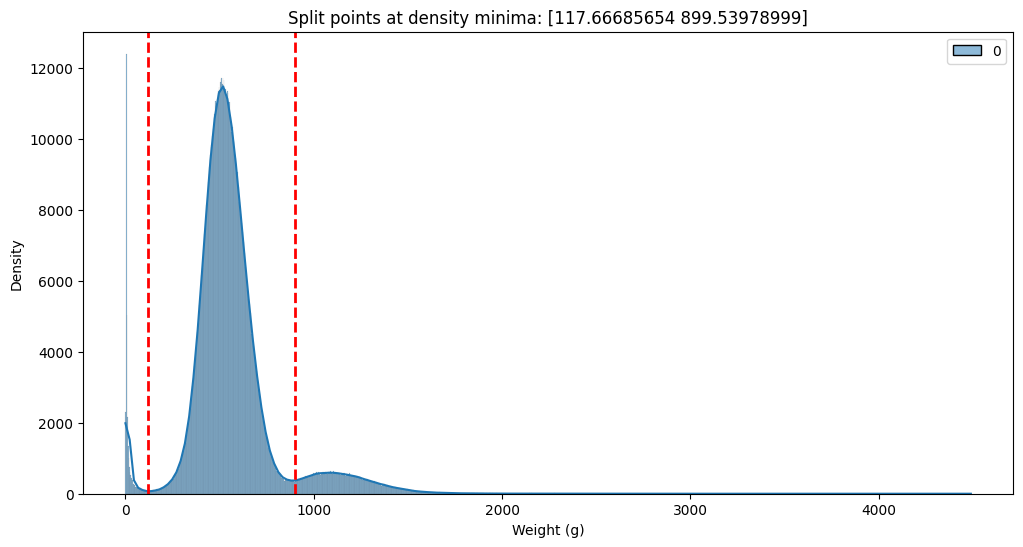

In [7]:
plt.figure(figsize=(12, 6))
kde_plot = sns.kdeplot(x, bw_adjust=1, fill=False, linewidth=2, color='black')

# Extract KDE curve data
xs, ys = kde_plot.get_lines()[0].get_data()

# --- Find local minima (valleys) ---
minima_idx = argrelextrema(ys, np.less)[0]
split_points = xs[minima_idx[:2]]
left, right = split_points[0], split_points[1]

# --- Plot histogram + KDE + split points ---
plt.clf()  # clear previous figure

plt.figure(figsize=(12, 6))
sns.histplot(x, kde=True, color='skyblue', alpha=0.5)

# Add split point lines
for sp in split_points:
    plt.axvline(sp, color='red', linestyle='--', linewidth=2)

plt.title(f"Split points at density minima: {split_points}")
plt.xlabel("Weight (g)")
plt.ylabel("Density")
plt.show()

## Fit Normal Distribution
After finding the minima of the distribution, I can trim the unnecessary data and begin fitting distributions to the dataset.

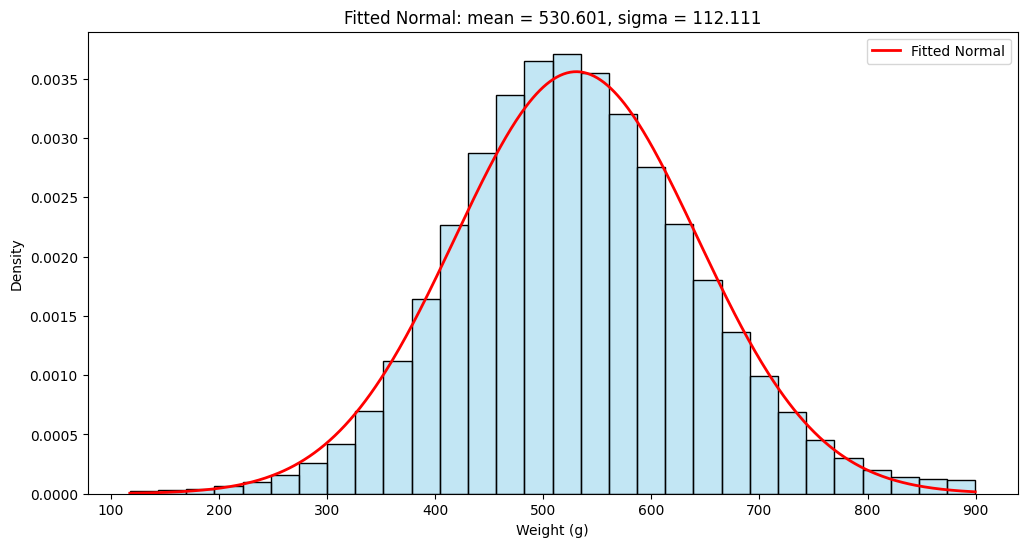

In [50]:
# --- Trim data between upper and lower bound ---
trimmed = x[(x >= left) & (x <= right)]

# --- Fit a normal distribution ---
mu, sigma = norm.fit(trimmed)

# --- Plot trimmed data + fitted normal curve ---
plt.figure(figsize=(12, 6))

# Histogram of trimmed data
sns.histplot(trimmed, bins=30, stat='density', color='skyblue', alpha=0.5)

# Normal curve
x_fit = np.linspace(trimmed.min(), trimmed.max(), 500)
normPDF = norm.pdf(x_fit, mu, sigma)
plt.plot(x_fit, normPDF, 'r-', linewidth=2, label='Fitted Normal')

plt.title(f"Fitted Normal: mean = {mu:.3f}, sigma = {sigma:.3f}")
plt.xlabel("Weight (g)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Fit Skewed Normal Distribution
After fitting the normal distribution, the histogram looked to me like it had a slight right skew to it. Taking the same data and using the same package, I fit the skewed normal distribution.

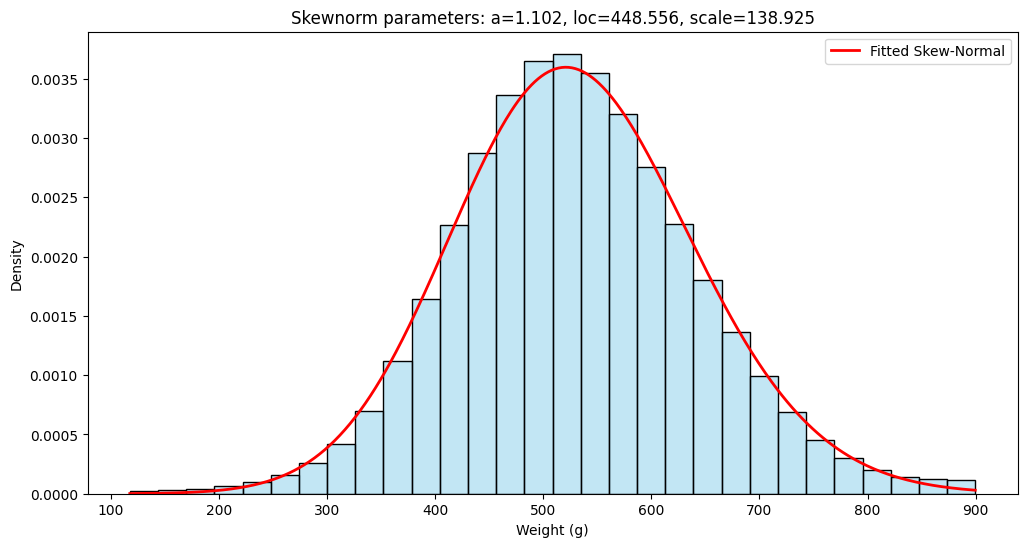

In [9]:
# --- Fit skew-normal distribution ---
a, loc, scale = skewnorm.fit(trimmed)

# --- Plot histogram + fitted skew-normal curve ---
plt.figure(figsize=(12, 6))

# Histogram of trimmed data
sns.histplot(trimmed, bins=30, stat='density', color='skyblue', alpha=0.5)

# Skew-normal PDF
x_fit = np.linspace(trimmed.min(), trimmed.max(), 500)
skewnormPDF = skewnorm.pdf(x_fit, a, loc, scale)
plt.plot(x_fit, skewnormPDF, 'r-', linewidth=2, label='Fitted Skew-Normal')

#
plt.title(f"Skewnorm parameters: a={a:.3f}, loc={loc:.3f}, scale={scale:.3f}")
plt.xlabel("Weight (g)")
plt.ylabel("Density")
plt.legend()
plt.show()

## Compare Fits
To compare the fits of the two distributions I calculated the MSE and found that the difference between the two was negligible. For simplicity's sake, I will continue using the normal distribution for future analysis.

In [42]:
def chi_squared_gof(data_column, distribution):
    data = np.asarray(data_column)
    n = len(data)

    # ---- Fit distribution ----
    params = distribution.fit(data)

    # ---- Number of bins (Freedman–Diaconis rule) ----
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    bin_width = 2 * iqr * n ** (-1/3)
    bins = int(np.ceil((data.max() - data.min()) / bin_width))

    # ---- Observed frequencies ----
    observed, bin_edges = np.histogram(data, bins=bins)

    # ---- Expected frequencies ----
    cdf_vals = distribution.cdf(bin_edges, *params)
    expected = np.diff(cdf_vals) * n

    # Remove bins where expected == 0
    mask = expected > 0
    observed = observed[mask]
    expected = expected[mask]

    # ---- Chi-squared statistic ----
    chi_stat = np.sum((observed - expected) ** 2 / expected)

    # Degrees of freedom:
    # (# bins - 1) - (# estimated parameters)
    dof = len(observed) - 1 - len(params)

    p_value = 1 - chi2.cdf(chi_stat, dof)

    return p_value


In [45]:
def mse(x, pdf):
    return np.sum((x-pdf)**2)

norm_chi2 = chi_squared_gof(x, norm)
skewnorm_chi2 = chi_squared_gof(x, skewnorm)
print("Chi-Squared P-value of normal distribution: " + str(norm_chi2))
print("Chi-Squared P-value of skewnorm distribution: " + str(skewnorm_chi2))
print("Chi-Squared P-value difference (skewnormMSE - normMSE): " + str(skewnorm_chi2 - norm_chi2))

Chi-Squared P-value of normal distribution: 0.0
Chi-Squared P-value of skewnorm distribution: 0.0
Chi-Squared P-value difference (skewnormMSE - normMSE): 0.0


# What is the average unavoidable trim for each bucket size?
Simmons would like us to target the lower bound of the weight bucket when making portioning decisions in order to minimize miscuts. When targeting the lower bound, there is a proportion of meat in each breast that is inevitably lost from breasts any larger than the absolute minimum. I want to explore what exactly that amount of waste is to see if modified bucket sizes or a different target weight rule could make a significant impact on the total waste of any given portioning decision.

### Expected Value of a Truncated Normal Distribution

$$ E[X] = \mu + \sigma\frac{\phi(\frac{a-\mu}{\sigma}) - \phi(\frac{b-\mu}{\sigma})}{\Phi(\frac{b-\mu}{\sigma}) - \Phi(\frac{a-\mu}{\sigma})}$$

Where
 * $\phi =$ The standard normal PDF
 * $\Phi =$ The standard normal CDF
 * $a,b = lb,ub$ of bucket range


In [55]:
a = 440
b = 490

alpha = (a - mu)/sigma
beta = (b - mu)/sigma

calculated_mean = mu + sigma*((norm.pdf(alpha)-norm.pdf(beta))/(norm.cdf(beta)-norm.cdf(alpha)))
print(calculated_mean)

466.07894921810816


### Estimating Breast Weight using Monte Carlo Simulation
My next step was to define a function that would preform a Monte Carlo estimate of $E[f(X) | a <= X <= b]$, where:
 * $f(X)$ ~ $Normal(\mu, \sigma^2)$
 * $a,b = lb,ub$ of bucket range
 * $U = UniformRV(f(a), f(b))$
 * $X = f^{-1}(U)$

Returns:
   * $\hat{\mu} =$ Estimated average of bucket range
   * $h = $ Half-width of estimate
   * $E[x] = $ Expected trim as a percentage of average weight

This function is a 3-step process. First, it finds the P-values of $a$ and $b$ and generates $n$ random variates from $U$. Then it enters all $n$ variates into the inverse CDF of the normal distribution to return their weight values in grams. Finally, it calculates and returns the desired statistics.

In [12]:
def mc_truncated_avg_pdf(mu, sigma, a, b, n=n, alpha=0.05):
    # Finds the P-value of the buckets upper and lower bounds
    Fa = norm.cdf(a, loc=mu, scale=sigma)
    Fb = norm.cdf(b, loc=mu, scale=sigma)

    # Generates an RV from the normal distribution within a given bucket
    U = np.random.uniform(Fa, Fb, n)
    X = norm.ppf(U, loc=mu, scale=sigma)

    # Calculates mean and HW with desired confidence
    mean_est = X.mean()
    s = X.std()
    z = norm.ppf(1 - alpha / 2)
    ci_half = z * s / np.sqrt(n)

    # Calculates the expected unavoidable trim
    expected_trim = (mean_est - a) / mean_est

    return mean_est, ci_half, expected_trim

### Determine Required Sample Size
To preform any sort of monte carlo simulation, I must first determine the required sample size to achieve my desired confidence. For this situation I am interested in finding the mean weight (g) +/- 1g with 95% confidence. Using normal approximation, the required sample size can be found using the equation:

$$n≥(\frac{z_{1−(α/2)}s}{ϵ})^2$$

Where ϵ is the desired half-width. Since the sample standard deviation I got from the normal fit is larger than the standard deviation from any of the bucket sizes, this number will be inflated to some extent. Regardless, it will provide me with at least my desired confidence.

In [11]:
n = pow((1.96*sigma/1.0), 2).astype(int)
n

np.int64(48284)

Simmons uses eight weight buckets, ranging from 0g to 1000g. I add all these buckets to a dictionary and iterate through the list while applying the Monte Carlo simulation method from above. This collects the estimated average weight of a breast, half-width of the estimate, and expected trim percentage associated with the bucket. and outputs the results to the console.

In [57]:
# Creates bucket ranges dictionary
ranges = {
#    "0-390": (0, 390), # Using this bucket with the lb rule results in a trim% of 1
    "390-440": (390, 440),
    "440-490": (440, 490),
    "490-540": (490, 540),
    "540-590": (540, 590),
    "590-640": (590, 640),
    "640-690": (640, 690),
    "690-1000": (690, 1000)
}

# Simulates buckets and adds results to dict
results = {
    label: dict(
        zip(
            ["estimated_mean", "95%_CI_halfwidth", "expected_trim%"],
            mc_truncated_avg_pdf(mu, sigma, low, high),
 #           mc_truncated_avg_pdf(502, 90.63, low, high) # CV model that Simmons provided
        )
    )
    for label, (low, high) in ranges.items()
}

# Print results
print(json.dumps(results, indent=2))


{
  "390-440": {
    "mean_pdf_estimate": 416.8813217633742,
    "95%_CI_halfwidth": 0.12738313011503952,
    "expected_trim%": 0.06448195292048203
  },
  "440-490": {
    "mean_pdf_estimate": 465.95832057956005,
    "95%_CI_halfwidth": 0.12828473770770712,
    "expected_trim%": 0.05570953330605414
  },
  "490-540": {
    "mean_pdf_estimate": 515.2695416616151,
    "95%_CI_halfwidth": 0.12799407918821323,
    "expected_trim%": 0.049041403806107324
  },
  "540-590": {
    "mean_pdf_estimate": 564.43777738253,
    "95%_CI_halfwidth": 0.1285039261711714,
    "expected_trim%": 0.043295786288181246
  },
  "590-640": {
    "mean_pdf_estimate": 613.6442656426354,
    "95%_CI_halfwidth": 0.12814373805360713,
    "expected_trim%": 0.03853089968643987
  },
  "640-690": {
    "mean_pdf_estimate": 662.8021415455412,
    "95%_CI_halfwidth": 0.12731144441668638,
    "expected_trim%": 0.03440263710127806
  },
  "690-1000": {
    "mean_pdf_estimate": 740.48318278746,
    "95%_CI_halfwidth": 0.39502542

# What is the Impact of Increasing the Number of Buckets?
Increasing the number of buckets that Simmons uses would decrease the difference between the lowest and highest weight in the range. This would in turn reduce the average trim percentage in every bucket but would come at the cost of potentially increasing space requirements and ordering complexity for the portioning plants.

In [58]:
base_low = 390
base_high = 690

partition_counts = [6, 7, 8, 9, 10, 11, 12]

def build_subranges(a, b, n_parts):
    edges = np.linspace(a, b, n_parts + 1)
    return {
        f"{round(edges[i],3)}-{round(edges[i+1],3)}": (edges[i], edges[i+1])
        for i in range(n_parts)
    }

results = {
    n_parts: {
            label: dict(
                zip(
                    ["estimated_mean", "95%_CI_halfwidth", "expected_trim%"],
                    mc_truncated_avg_pdf(502, 9063, low, high),
                )
            )
        for label, (low, high) in build_subranges(base_low, base_high, n_parts).items()
    }
    for n_parts in partition_counts
}

avg_trim_by_partition = {
    n_parts: np.mean([bucket["expected_trim%"]
                      for bucket in part_results.values()])
    for n_parts, part_results in results.items()
}

print(json.dumps(avg_trim_by_partition, indent=2))

{
  "6": 0.047523196995648616,
  "7": 0.04072060785307101,
  "8": 0.0355873258052255,
  "9": 0.0316605577333262,
  "10": 0.02854280759586768,
  "11": 0.025920094849888567,
  "12": 0.023797283771876187
}


# What Bucket Sizes Minimize the Difference in Trim Percentage?
This requires learning nonlinear optimization. is it worth?

min $\delta$


# Does Accepting Miscuts Reduce Waste?
Simmons does not currently have the capacity to handle a large number of miscuts. This question explores if it is worth accepting some miscuts as a tradeoff for reducing the total amount of waste. To find the answer to this question, I modified the Monte Carlo simulation to account for